# Adaptive Fusion

**Universe:** 20 large-cap US stocks | **Rebalance:** every 10 trading days | **Capital:** $10,000

**Execution rule:** signal at day-*t* close &#8594; trade at day-*(t+1)* open (or close proxy)

Six strategies compared:
- **S0 Price-Only MV** &#8211; Rolling mean returns &#8594; Mean-Variance optimisation (no sentiment)
- **S1 Sentiment+MV** &#8211; Rolling returns + news sentiment tilt &#8594; Mean-Variance optimisation
- **S2 Sentiment&#8594;BL&#8594;MV** &#8211; Single-source news views &#8594; Black&#8211;Litterman &#8594; MV
- **S3 Hedge Fusion&#8594;BL&#8594;MV** &#8211; Adaptive multi-source weighting (Hedge) &#8594; BL &#8594; MV
- **Equal Weight** &#8211; 1/N across all 20 stocks, buy &amp; hold (no rebalancing)
- **S&amp;P 500 Buy &amp; Hold** &#8211; SPY benchmark, full capital at start, no rebalancing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re, warnings, logging
from scipy.stats import spearmanr, norm
import yfinance as yf
import cvxpy as cp

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')
log = logging.getLogger('qts')

# Paths
# Direction to the project root, non hard coding
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Processed_Data').exists()), Path.cwd())
NEWS_DIR   = ROOT / 'Processed_Data' / 'news_sentiment_daily'
TWEETS_DIR = ROOT / 'Processed_Data' / 'tweets_sentiment_daily'

# Configuration
Config = dict(
    # Market parameters
    initial_capital     = 10_000,
    rebalance_days      = 10,
    lookback_cov        = 120,       # trailing days for covariance
    max_weight          = 0.15,      # per-asset weight cap (Encourages diversification)
    risk_aversion       = 2.0,       # gamma in MV
    turnover_penalty    = 0.001,     # L1 turnover penalty in MV

    # Backtest window (warmup uses data before this)
    backtest_start      = '2024-10-10',
    backtest_end        = '2025-10-10',

    # Transaction costs - Based on T212 for US stocks
    sec_fee_rate        = 0.0000278, # SEC fee: $/$ of sell value
    finra_fee_per_share = 0.000195,  # FINRA fee: $/share sold

    # Black-Litterman
    tau                 = 0.5,       # ~0.5 for daily returns (calibrated)
    bl_delta            = 2.5,       # risk aversion for equilibrium
    kappa               = 0.01,      # alpha -> view return scale
    eta                 = 1.0,       # view uncertainty scale

    # Baseline strategy parameters
    beta_sent           = 0.0005,    # S1: sentiment tilt scale
    hedge_lr            = 0.5,       # S3: Hedge algorithm learning rate

    # Evaluation
    rolling_sharpe_win  = 60, # 60-day rolling window for Sharpe ratio calculation

    # Horizon & slippage
    horizon_days        = 10,        # Rebalance every 10 days
    slippage_bps        = 2.0,       # Buying and selling at open is unrealistic, so we assume a 2% slippage on the trade value to account for this.
    min_weight          = 0.02,      # drop positions below 2%, as they wont generate enough returns to cover costs + slippage

    # Cross-sectional normalisation
    cs_norm             = 'winsor_z',   # 'winsor_z' or 'rank_z'
    winsor_q            = 0.01,         # winsorise at 1%/99%

    # Momentum & reversal
    mom_windows         = [20, 60],     # momentum horizons (trading days)
    reversal_window     = 10,           # short-term reversal horizon

    # Signal evaluation
    topk_eval           = 5,            # top-k for bucket evaluation

    # BL confidence mapping
    conf_min            = 0.20,
    conf_max            = 1.50,
    conf_alpha_scale    = 1.0,          # |alpha| -> confidence boost
    conf_disp_scale     = 1.0,          # dispersion -> confidence penalty
)

print()
for k, v in Config.items():
    print(f'  {k:24s} = {v}')


  initial_capital          = 10000
  rebalance_days           = 10
  lookback_cov             = 120
  max_weight               = 0.15
  risk_aversion            = 2.0
  turnover_penalty         = 0.001
  backtest_start           = 2024-10-10
  backtest_end             = 2025-10-10
  sec_fee_rate             = 2.78e-05
  finra_fee_per_share      = 0.000195
  tau                      = 0.5
  bl_delta                 = 2.5
  kappa                    = 0.01
  eta                      = 1.0
  beta_sent                = 0.0005
  hedge_lr                 = 0.5
  rolling_sharpe_win       = 60
  horizon_days             = 10
  slippage_bps             = 2.0
  min_weight               = 0.02
  cs_norm                  = winsor_z
  winsor_q                 = 0.01
  mom_windows              = [20, 60]
  reversal_window          = 10
  topk_eval                = 5
  conf_min                 = 0.2
  conf_max                 = 1.5
  conf_alpha_scale         = 1.0
  conf_disp_scale          = 1.0


---
## 1. Data Loading & Panel Construction

Load sentiment from `news_sentiment_daily/` and `tweets_sentiment_daily/` CSVs.
Fetch OHLCV price data via **yfinance** for all common tickers.
Merge into a unified `[date, ticker]` panel.


In [2]:
# Helpers
def normalise_ticker(ticker):
    return ticker.upper().replace('.', '-')

def find_col(cols, candidates):
    lc = {c.lower().strip(): c for c in cols}
    for c in candidates:
        if c in lc:
            return lc[c]
    return None

# ── LOAD SENTIMENT FROM CSVs ─────────────────────────────────────────

print('=' * 70)
print('  LOADING NEWS SENTIMENT DATA')
print('=' * 70)

news_files = sorted(NEWS_DIR.glob('*.csv'))
print(f'Found {len(news_files)} CSV files in {NEWS_DIR.name}/')

news_sent_frames = []
news_tickers = []
for f in news_files:
    m = re.match(r'^(.+?)_news_sentiment_daily$', f.stem, re.I)
    ticker = normalise_ticker(m.group(1) if m else f.stem.split('_')[0])
    df = pd.read_csv(f)
    date_col = find_col(df.columns, ['date', 'datetime', 'timestamp'])
    sent_col = find_col(df.columns, ['avg_sentiment', 'sentiment', 'compound', 'score'])
    if date_col is None or sent_col is None:
        continue
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])
    daily = df.groupby(date_col).agg({sent_col: 'mean'}).rename(columns={sent_col: ticker})
    news_sent_frames.append(daily)
    news_tickers.append(ticker)

news_sent_wide = pd.concat(news_sent_frames, axis=1).sort_index()
news_sent_wide.index.name = 'date'
print(f'News sentiment: {news_sent_wide.shape}')

# ── TWEETS SENTIMENT ─────────────────────────────────────────────────

print('\n' + '=' * 70)
print('  LOADING TWEETS SENTIMENT DATA')
print('=' * 70)

tweets_files = sorted(TWEETS_DIR.glob('*.csv'))
print(f'Found {len(tweets_files)} files in {TWEETS_DIR.name}/')

tweets_sent_frames = []
for f in tweets_files:
    m = re.match(r'^(.+?)_tweets_sentiment_daily$', f.stem, re.I)
    ticker = normalise_ticker(m.group(1) if m else f.stem.split('_')[0])
    df = pd.read_csv(f)
    date_col = find_col(df.columns, ['date'])
    sent_col = find_col(df.columns, ['avg_sentiment'])
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])
    daily = df.groupby(date_col).agg({sent_col: 'mean'}).rename(columns={sent_col: ticker})
    tweets_sent_frames.append(daily)

tweets_sent_wide = pd.concat(tweets_sent_frames, axis=1).sort_index()
tweets_sent_wide.index.name = 'date'
print(f'Tweets sentiment: {tweets_sent_wide.shape}')

# ── FETCH PRICES FROM YFINANCE ───────────────────────────────────────

TICKERS = sorted(set(news_tickers) & set(tweets_sent_wide.columns))
print(f'\nCommon tickers ({len(TICKERS)}): {TICKERS}')

# Determine date range from sentiment data
sent_start = min(news_sent_wide.index.min(), tweets_sent_wide.index.min())
sent_end   = max(news_sent_wide.index.max(), tweets_sent_wide.index.max())

# Map tickers to yfinance symbols (BRK-B -> BRK-B is fine for yfinance)
yf_symbols = TICKERS.copy()
print(f'\nDownloading OHLCV via yfinance for {len(yf_symbols)} tickers ...')
print(f'  Date range: {sent_start.date()} to {sent_end.date()}')

raw_yf = yf.download(
    yf_symbols,
    start=sent_start - pd.Timedelta(days=5),
    end=sent_end + pd.Timedelta(days=5),
    progress=True, auto_adjust=True,
    group_by='ticker',
)

# ── Extract close, open, volume panels ────────────────────────────────

close_frames, open_frames, volume_frames = {}, {}, {}
high_frames, low_frames = {}, {}
for ticker in TICKERS:
    try:
        if len(yf_symbols) == 1:
            ticker_data = raw_yf
        else:
            ticker_data = raw_yf[ticker]
        close_frames[ticker]  = ticker_data['Close'].squeeze()
        open_frames[ticker]   = ticker_data['Open'].squeeze()
        high_frames[ticker]   = ticker_data['High'].squeeze()
        low_frames[ticker]    = ticker_data['Low'].squeeze()
        volume_frames[ticker] = ticker_data['Volume'].squeeze()
    except Exception as e:
        print(f'  Warning: {ticker} extraction failed: {e}')

close_panel  = pd.DataFrame(close_frames).sort_index()
open_panel   = pd.DataFrame(open_frames).sort_index()
high_panel   = pd.DataFrame(high_frames).sort_index()
low_panel    = pd.DataFrame(low_frames).sort_index()
volume_panel = pd.DataFrame(volume_frames).sort_index()

# Remove timezone if present
for p in [close_panel, open_panel, high_panel, low_panel, volume_panel]:
    if p.index.tz is not None:
        p.index = p.index.tz_localize(None)

close_panel.index.name = 'date'
open_panel.index.name = 'date'
volume_panel.index.name = 'date'

# ── Align to trading calendar ─────────────────────────────────────────

# Use close_panel trading dates as the master calendar
trading_dates = close_panel.index

# Filter to only dates where we have price data
valid_mask = close_panel.notna().any(axis=1)
trading_dates = trading_dates[valid_mask]
close_panel  = close_panel.loc[trading_dates]
open_panel   = open_panel.loc[trading_dates]
high_panel   = high_panel.loc[trading_dates]
low_panel    = low_panel.loc[trading_dates]
volume_panel = volume_panel.loc[trading_dates]

# Align sentiment to trading dates
news_sent_wide   = news_sent_wide.reindex(index=trading_dates, columns=TICKERS)
tweets_sent_wide = tweets_sent_wide.reindex(index=trading_dates, columns=TICKERS)

# Forward-fill minor gaps in prices (weekends already excluded)
close_panel  = close_panel.ffill(limit=3)
open_panel   = open_panel.ffill(limit=3)
high_panel   = high_panel.ffill(limit=3)
low_panel    = low_panel.ffill(limit=3)
volume_panel = volume_panel.ffill(limit=3).fillna(0)

# ── Summary ───────────────────────────────────────────────────────────

n_dates   = len(trading_dates)
n_tickers = len(TICKERS)
print(f'\nPrice data loaded from yfinance:')
print(f'  Close panel  : {close_panel.shape}\n'
      f'  High panel   : {high_panel.shape}\n'
      f'  Low panel    : {low_panel.shape}')
print(f'  Open panel   : {open_panel.shape}')
print(f'  Volume panel : {volume_panel.shape}')
print(f'  Trading days : {n_dates} ({trading_dates[0].date()} to {trading_dates[-1].date()})')
print(f'  Close NaN%   : {close_panel.isna().mean().mean()*100:.1f}%')
print(f'  News NaN%    : {news_sent_wide.isna().mean().mean()*100:.1f}%')
print(f'  Tweets NaN%  : {tweets_sent_wide.isna().mean().mean()*100:.1f}%')

  LOADING NEWS SENTIMENT DATA
Found 20 CSV files in news_sentiment_daily/
News sentiment: (796, 20)

  LOADING TWEETS SENTIMENT DATA
Found 20 files in tweets_sentiment_daily/
Tweets sentiment: (732, 20)

Common tickers (20): ['AAPL', 'AMZN', 'AVGO', 'BRK-B', 'GOOGL', 'HD', 'JNJ', 'JPM', 'LLY', 'MA', 'META', 'MSFT', 'NVDA', 'ORCL', 'PG', 'TSLA', 'UNH', 'V', 'WMT', 'XOM']

  Date range: 2023-10-10 to 2025-12-31


[*********************100%***********************]  20 of 20 completed


Price data loaded from yfinance:
  Close panel  : (563, 20)
  High panel   : (563, 20)
  Low panel    : (563, 20)
  Open panel   : (563, 20)
  Volume panel : (563, 20)
  Trading days : 563 (2023-10-05 to 2026-01-02)
  Close NaN%   : 0.0%
  News NaN%    : 16.8%
  Tweets NaN%  : 13.8%


In [3]:
# Build unified long-format panel for display 
close_long = close_panel.stack().rename('close_price').reset_index()
close_long.columns = ['date', 'ticker', 'close_price']

panel_long = close_long.copy()

if open_panel is not None:
    tmp = open_panel.stack().rename('open_price').reset_index()
    tmp.columns = ['date', 'ticker', 'open_price']
    panel_long = panel_long.merge(tmp, on=['date', 'ticker'], how='left')

tmp_n = news_sent_wide.stack().rename('news_sentiment').reset_index()
tmp_n.columns = ['date', 'ticker', 'news_sentiment']
panel_long = panel_long.merge(tmp_n, on=['date', 'ticker'], how='left')

tmp_t = tweets_sent_wide.stack().rename('tweet_sentiment').reset_index()
tmp_t.columns = ['date', 'ticker', 'tweet_sentiment']
panel_long = panel_long.merge(tmp_t, on=['date', 'ticker'], how='left')

panel_long['news_missing']  = panel_long['news_sentiment'].isna().astype(int)
panel_long['tweet_missing'] = panel_long['tweet_sentiment'].isna().astype(int)
panel_long['news_count']    = 1 - panel_long['news_missing']
panel_long['tweet_count']   = 1 - panel_long['tweet_missing']
panel_long['news_sentiment']  = panel_long['news_sentiment'].fillna(0.0)
panel_long['tweet_sentiment'] = panel_long['tweet_sentiment'].fillna(0.0)

print(f'Unified panel: {panel_long.shape[0]:,} rows x {panel_long.shape[1]} columns')
print(f'Columns: {list(panel_long.columns)}')
n_valid = panel_long.dropna(subset=['close_price']).shape[0]
print(f'Samples with valid close price: {n_valid:,} / {panel_long.shape[0]:,}')
print()
panel_long.head()

Unified panel: 11,260 rows x 10 columns
Columns: ['date', 'ticker', 'close_price', 'open_price', 'news_sentiment', 'tweet_sentiment', 'news_missing', 'tweet_missing', 'news_count', 'tweet_count']
Samples with valid close price: 11,260 / 11,260



,date,ticker,close_price,open_price,news_sentiment,tweet_sentiment,news_missing,tweet_missing,news_count,tweet_count
0,2023-10-05,AAPL,172.883865,171.776829,0.0,0.0,1,1,0,0
1,2023-10-05,AMZN,125.959999,126.709999,0.0,0.0,1,1,0,0
2,2023-10-05,AVGO,80.194321,79.829297,0.0,0.0,1,1,0,0
3,2023-10-05,BRK-B,345.059998,343.700012,0.0,0.0,1,1,0,0
4,2023-10-05,GOOGL,134.057098,134.057098,0.0,0.0,1,1,0,0


---
## 2. Price Data Summary & S&P 500 Benchmark

Prices fetched from yfinance (OHLCV). Download SPY for benchmark comparison.


In [4]:
# Price data summary
print('Price data: fetched via yfinance')
print(f'  Close range : {close_panel.min().min():.2f} - {close_panel.max().max():.2f}')
print(f'  Open range  : {open_panel.min().min():.2f} - {open_panel.max().max():.2f}')
print(f'  High range  : {high_panel.min().min():.2f} - {high_panel.max().max():.2f}')
print(f'  Low range   : {low_panel.min().min():.2f} - {low_panel.max().max():.2f}')
print(f'  Volume range: {volume_panel.min().min():.0f} - {volume_panel.max().max():.0f}')
print(f'  NaN% close  : {close_panel.isna().mean().mean()*100:.1f}%')

# S&P 500 (SPY) benchmark
spy_close = None
dt_start = trading_dates[0]
dt_end   = trading_dates[-1]

print(f'\nDownloading SPY via yfinance ({dt_start.date()} to {dt_end.date()})...')
try:
    spy_df = yf.download(
        'SPY',
        start=dt_start - pd.Timedelta(days=5),
        end=dt_end + pd.Timedelta(days=5),
        progress=False, auto_adjust=True,
    )
    if len(spy_df) > 0:
        spy_close = spy_df['Close'].squeeze()
        spy_close.index = pd.to_datetime(spy_close.index).tz_localize(None)
        spy_close = spy_close.reindex(trading_dates, method='ffill')
        print(f'  SPY loaded: {spy_close.notna().sum()} trading days')
    else:
        print('  SPY download returned empty DataFrame')
except Exception as e:
    print(f'  SPY download failed: {e}')

if spy_close is None:
    print('\n  SPY not available. Using equal-weight proxy as placeholder.')
    ew_ret = close_panel.pct_change().mean(axis=1).fillna(0)
    spy_close = (1 + ew_ret).cumprod() * 100
    spy_close = spy_close.reindex(trading_dates)

print(f'\nSPY price: {spy_close.iloc[0]:.2f} -> {spy_close.iloc[-1]:.2f}')


Price data: fetched via yfinance
  Close range : 40.30 - 1108.09
  Open range  : 40.42 - 1100.16
  High range  : 40.85 - 1110.14
  Low range   : 39.20 - 1096.27
  Volume range: 932800 - 1142269000
  NaN% close  : 0.0%

  SPY loaded: 563 trading days

SPY price: 412.59 -> 683.17


---
## 3. Feature Engineering

Compute features from yfinance OHLCV data and sentiment CSVs, then build
factor + context matrices used across all strategies. All features use
**only** data available at time *t* (no forward-looking leakage).

**Factors** (z-scored cross-sectionally per date):
- Sentiment: `news_sent`, `tweet_sent`
- Technical Analysis: `rsi_14`, `macd_hist`, `bband_pctb`, `sma_crossover`
- Sentiment-derived: `sent_momentum`, `sent_dispersion`

**Context** (per stock, per date — used for confidence penalties in S2/S3):
`news_missing`, `tweet_missing`, `vol_regime_quintile` (5-dim one-hot)

In [5]:
# Cross-sectional normalisation
from scipy.stats import norm as _norm

def winsorize_1d(x, q=0.01):
    """Winsorise 1-D array at [q, 1-q] quantiles, preserving NaNs."""
    out = x.copy()
    finite = np.isfinite(out)
    if finite.sum() < 3:
        return out
    lo = np.nanquantile(out[finite], q)
    hi = np.nanquantile(out[finite], 1 - q)
    out[finite] = np.clip(out[finite], lo, hi)
    return out

def cs_zscore_1d(x):
    """Cross-sectional z-score of finite values; NaNs stay NaN."""
    out = np.full_like(x, np.nan, dtype=float)
    finite = np.isfinite(x)
    if finite.sum() < 2:
        out[finite] = 0.0
        return out
    vals = x[finite]
    mu, sigma = vals.mean(), vals.std()
    if sigma < 1e-12:
        out[finite] = 0.0
    else:
        out[finite] = (vals - mu) / sigma
    return out

def cs_rank_to_z_1d(x):
    """Rank finite values → uniform → inverse-normal z. NaNs stay NaN."""
    out = np.full_like(x, np.nan, dtype=float)
    finite = np.isfinite(x)
    N = finite.sum()
    if N < 3:
        out[finite] = 0.0
        return out
    from scipy.stats import rankdata
    ranks = rankdata(x[finite], method='average')
    uniform = (ranks - 0.5) / N
    out[finite] = _norm.ppf(uniform)
    return out

def cs_normalize(x, method='winsor_z', winsor_q=0.01):
    """Normalize a cross-sectional vector using the chosen method."""
    if method == 'winsor_z':
        return cs_zscore_1d(winsorize_1d(x, winsor_q))
    elif method == 'rank_z':
        return cs_rank_to_z_1d(x)
    else:
        raise ValueError(f'Unknown cs_norm method: {method}')

print('Cross-sectional normalisation helpers defined.')

Cross-sectional normalisation helpers defined.


In [6]:
# Feature engineering
log_returns    = np.log(close_panel / close_panel.shift(1))

# Technical Analysis Features 

# RSI (14-day) rescaled to [-1, 1]
_delta  = close_panel.diff()
_gain   = _delta.clip(lower=0).ewm(alpha=1/14, min_periods=14, adjust=False).mean()
_loss   = (-_delta.clip(upper=0)).ewm(alpha=1/14, min_periods=14, adjust=False).mean()
_rs     = _gain / (_loss + 1e-10)
rsi_14  = (100 - 100 / (1 + _rs)) / 50 - 1        # rescale [0,100] -> [-1,1]

# MACD histogram: MACD(12,26) minus Signal(9)
ema_12     = close_panel.ewm(span=12, min_periods=12, adjust=False).mean()
ema_26     = close_panel.ewm(span=26, min_periods=26, adjust=False).mean()
macd_line = ema_12 - ema_26
signal    = macd_line.ewm(span=9, min_periods=9, adjust=False).mean()
macd_hist  = macd_line - signal

# Bollinger %B (20-day, 2 sigma)
_bb_mid   = close_panel.rolling(20, min_periods=20).mean()
_bb_std   = close_panel.rolling(20, min_periods=20).std()
_bb_upper = _bb_mid + 2 * _bb_std
_bb_lower = _bb_mid - 2 * _bb_std
_bb_width = _bb_upper - _bb_lower
bband_pctb = ((close_panel - _bb_lower) / _bb_width.where(_bb_width > 1e-6, np.nan)).clip(-0.5, 1.5)

# SMA crossover: SMA(10) / SMA(50) - 1
sma_10 = close_panel.rolling(10, min_periods=10).mean()
sma_50 = close_panel.rolling(50, min_periods=50).mean()
sma_crossover = (sma_10 / sma_50 - 1).clip(-0.5, 0.5)

# Momentum & reversal features 

mom_features = {}
for w in Config['mom_windows']:
    mom_features[f'mom_{w}'] = np.log(close_panel / close_panel.shift(w))

# Short-term reversal (negative momentum = reversal signal)
rev_window = Config['reversal_window']
reversal = -np.log(close_panel / close_panel.shift(rev_window))

#  Sentiment-derived features

blended_sent   = (news_sent_wide.fillna(0) + tweets_sent_wide.fillna(0)) / 2
sent_momentum  = blended_sent.rolling(10, min_periods=5).mean() - blended_sent.rolling(30, min_periods=10).mean()
sent_dispersion = (news_sent_wide.fillna(0) - tweets_sent_wide.fillna(0)).abs()

# Sentiment decay: exponential half-life of 5 days captures recency
sent_ema5  = blended_sent.ewm(halflife=5, min_periods=3).mean()

# Sentiment x momentum interaction: sentiment confirming momentum is a stronger signal
sent_x_mom = sent_ema5 * mom_features['mom_20']

print('Features computed:')
for name, feat in [('log_returns', log_returns), ('rsi_14', rsi_14),
                   ('macd_hist', macd_hist), ('bband_pctb', bband_pctb),
                   ('sma_crossover', sma_crossover),
                   ('sent_momentum', sent_momentum), ('sent_dispersion', sent_dispersion)] + \
                  [(k, v) for k, v in mom_features.items()] + \
                  [('reversal', reversal)]:
    pct_nan = feat.isna().mean().mean() * 100
    print(f'  {name:20s}: {feat.shape}, NaN%={pct_nan:.0f}%')

# ── Build factor & context matrices ──────────────────────────────────

# Original 8 + momentum + reversal
FACTOR_NAMES = ['news_sent', 'tweet_sent', 'rsi_14', 'macd_hist',
                'bband_pctb', 'sma_crossover', 'sent_momentum', 'sent_dispersion',
                'sent_ema5', 'sent_x_mom']
for w in Config['mom_windows']:
    FACTOR_NAMES.append(f'mom_{w}')
FACTOR_NAMES.append(f'rev_{Config["reversal_window"]}')
N_FACTORS = len(FACTOR_NAMES)
N_CONTEXT = 7  # 2 missing flags + 5 vol-regime bins
MIN_IDX   = max(50, max(Config['mom_windows']) + 1)

factor_arr  = np.full((n_dates, n_tickers, N_FACTORS), np.nan)
context_arr = np.zeros((n_dates, n_tickers, N_CONTEXT))
target_arr  = np.full((n_dates, n_tickers), np.nan)

for di in range(MIN_IDX, n_dates):
    news_score = news_sent_wide.iloc[di].values.astype(float)
    tweet_score = tweets_sent_wide.iloc[di].values.astype(float)
    rsi_val    = rsi_14.iloc[di].values.astype(float)
    macd_val   = macd_hist.iloc[di].values.astype(float)
    bband_val  = bband_pctb.iloc[di].values.astype(float)
    sma_val    = sma_crossover.iloc[di].values.astype(float)
    sent_mom_val  = sent_momentum.iloc[di].values.astype(float)
    sent_disp_val = sent_dispersion.iloc[di].values.astype(float)

    sent_ema_val   = sent_ema5.iloc[di].values.astype(float)
    sent_x_mom_val = sent_x_mom.iloc[di].values.astype(float)

    # Gather all raw features (preserving NaNs for now)
    raw_list = [news_score, tweet_score, rsi_val, macd_val, bband_val,
                sma_val, sent_mom_val, sent_disp_val, sent_ema_val, sent_x_mom_val]
    for w in Config['mom_windows']:
        raw_list.append(mom_features[f'mom_{w}'].iloc[di].values.astype(float))
    raw_list.append(reversal.iloc[di].values.astype(float))

    # Cross-sectional normalisation per feature
    for k, raw_vec in enumerate(raw_list):
        normed = cs_normalize(raw_vec, method=Config['cs_norm'], winsor_q=Config['winsor_q'])
        # Fill remaining NaNs with 0.0 (neutral)
        factor_arr[di, :, k] = np.nan_to_num(normed, nan=0.0, posinf=0.0, neginf=0.0)

    # Context features
    news_missing  = np.where(np.isnan(news_score), 1.0, 0.0)
    tweet_missing = np.where(np.isnan(tweet_score), 1.0, 0.0)

    vol_raw = np.nan_to_num(
        log_returns.iloc[max(0, di-20):di+1].std().values,
        nan=0.01)
    try:
        q_labels = pd.qcut(pd.Series(vol_raw), 5, labels=False, duplicates='drop')
    except ValueError:
        q_labels = pd.Series([2] * n_tickers)
    vol_regime_onehot = np.zeros((n_tickers, 5))
    for j in range(n_tickers):
        qi = int(q_labels.iloc[j]) if not pd.isna(q_labels.iloc[j]) else 2
        vol_regime_onehot[j, min(qi, 4)] = 1.0

    context_arr[di, :, 0]   = news_missing
    context_arr[di, :, 1]   = tweet_missing
    context_arr[di, :, 2:7] = vol_regime_onehot

    # Target: H-day forward log return (training only)
    H = Config['horizon_days']
    if di + H < n_dates:
        fwd = close_panel.iloc[di + H].values
        cur = close_panel.iloc[di].values
        valid = (fwd > 0) & (cur > 0) & np.isfinite(fwd) & np.isfinite(cur)
        target_arr[di] = np.where(valid, np.log(fwd / cur), np.nan)

# Summary 

n_feat_dates = np.all(np.isfinite(factor_arr), axis=(1, 2)).sum()
n_tgt_dates  = np.any(np.isfinite(target_arr), axis=1).sum()
print(f'\nFeature matrices built:')
print(f'  factor_arr  : {factor_arr.shape}  ({n_feat_dates} valid dates)')
print(f'  context_arr : {context_arr.shape}')
print(f'  target_arr  : {target_arr.shape}  ({n_tgt_dates} dates with targets)')
print(f'\nFactor set ({N_FACTORS}): {FACTOR_NAMES}')

# Sanity check: no Inf in factor array
assert np.all(np.isfinite(factor_arr[MIN_IDX:])), 'factor_arr contains non-finite values!'
print('Sanity check passed: no Inf/NaN in factor_arr.')

Features computed:
  log_returns         : (563, 20), NaN%=0%
  rsi_14              : (563, 20), NaN%=2%
  macd_hist           : (563, 20), NaN%=6%
  bband_pctb          : (563, 20), NaN%=3%
  sma_crossover       : (563, 20), NaN%=9%
  sent_momentum       : (563, 20), NaN%=2%
  sent_dispersion     : (563, 20), NaN%=0%
  mom_20              : (563, 20), NaN%=4%
  mom_60              : (563, 20), NaN%=11%
  reversal            : (563, 20), NaN%=2%

Feature matrices built:
  factor_arr  : (563, 20, 13)  (502 valid dates)
  context_arr : (563, 20, 7)
  target_arr  : (563, 20)  (492 dates with targets)

Factor set (13): ['news_sent', 'tweet_sent', 'rsi_14', 'macd_hist', 'bband_pctb', 'sma_crossover', 'sent_momentum', 'sent_dispersion', 'sent_ema5', 'sent_x_mom', 'mom_20', 'mom_60', 'rev_10']
Sanity check passed: no Inf/NaN in factor_arr.


---
## 4. Model Components

### A) Hedge Algorithm Fusion (S3)

Multi-source sentiment signals (news + tweets) combined using the Hedge algorithm.
At each rebalance, source weights are updated via multiplicative exponential updates
based on their recent Spearman IC:

$$w_i^{(t+1)} = \frac{w_i^{(t)} \cdot \exp\!\bigl(\eta \cdot \text{IC}_i^{(t)}\bigr)}{\sum_j w_j^{(t)} \cdot \exp\!\bigl(\eta \cdot \text{IC}_j^{(t)}\bigr)}$$

where $w_i$ is the weight for source $i$ (news or tweets), $\eta$ is the learning rate, and $\text{IC}_i$ is the Spearman rank correlation between source $i$'s past predictions and realised returns.

### B) Black-Litterman Integration

Combines market equilibrium returns with sentiment-derived views using Bayesian updating:

$$\boldsymbol{\mu}_{\text{BL}} = \bigl[(\tau \Sigma)^{-1} + P^\top \Omega^{-1} P\bigr]^{-1} \bigl[(\tau \Sigma)^{-1} \boldsymbol{\pi} + P^\top \Omega^{-1} \mathbf{Q}\bigr]$$

where:
- $\boldsymbol{\pi} = \delta \Sigma \mathbf{w}_{\text{mkt}}$ — equilibrium expected returns
- $\mathbf{Q} = \kappa \cdot \mathbf{z}$ — view returns from sentiment z-scores
- $\Omega = \text{diag}\!\bigl(\eta \cdot \text{diag}(\Sigma) \,/\, \mathbf{c}\bigr)$ — view uncertainty (lower confidence = higher uncertainty)
- $\tau$ — scalar controlling how much weight the prior gets relative to views

### C) Mean-Variance Optimisation

Long-only constrained portfolio with turnover penalty:

$$\max_{\mathbf{w}} \quad \mathbf{w}^\top \boldsymbol{\mu} - \frac{\gamma}{2}\, \mathbf{w}^\top \Sigma\, \mathbf{w} - \lambda \|\mathbf{w} - \mathbf{w}_{\text{prev}}\|_1$$

subject to $\mathbf{w} \geq 0$, $\sum w_i = 1$, and $w_i \leq w_{\max}$.

In [7]:
# B) BLACK-LITTERMAN

def shrink_covariance(return_window):
    num_observations = return_window.shape[0]
    num_assets = return_window.shape[1]

    sample_cov = return_window.cov().values
    mu_hat = np.trace(sample_cov) / num_assets
    target = mu_hat * np.eye(num_assets)

    delta = sample_cov - target
    squared_distance = (delta ** 2).sum() / num_assets

    denom = ((num_observations + 1 - 2.0 / num_assets) * squared_distance
             + np.trace(sample_cov @ sample_cov) / num_assets + 1e-10)
    shrinkage = np.clip(squared_distance / denom, 0.0, 1.0)

    return (1 - shrinkage) * sample_cov + shrinkage * target


def black_litterman_posterior(pi, sigma, Q, omega, tau):
    num_assets = len(pi)
    P = np.eye(num_assets)
    tau_sigma = tau * sigma

    inv_tau_sigma = np.linalg.inv(tau_sigma + 1e-10 * np.eye(num_assets))
    inv_omega = np.linalg.inv(omega + 1e-10 * np.eye(num_assets))

    posterior_precision = inv_tau_sigma + P.T @ inv_omega @ P
    posterior_cov = np.linalg.inv(posterior_precision + 1e-10 * np.eye(num_assets))

    return posterior_cov @ (inv_tau_sigma @ pi + P.T @ inv_omega @ Q)


def compute_view_uncertainty(sigma, confidence, eta=1.0):
    base_diag = np.diag(sigma)
    omega_diag = eta * base_diag / (confidence + 1e-8)
    return np.diag(omega_diag)


# C) MEAN-VARIANCE OPTIMISER

def mv_optimize(mu, sigma, prev_weights=None, risk_aversion=2.0,
                turnover_penalty=0.001, max_weight=0.15):
    num_assets = len(mu)
    weights = cp.Variable(num_assets)

    ret  = mu @ weights
    risk = cp.quad_form(weights, cp.psd_wrap(sigma))
    obj  = ret - (risk_aversion / 2) * risk

    if prev_weights is not None and turnover_penalty > 0:
        obj -= turnover_penalty * cp.norm(weights - prev_weights, 1)

    constraints = [cp.sum(weights) == 1, weights >= 0, weights <= max_weight]
    prob = cp.Problem(cp.Maximize(obj), constraints)

    for solver in [cp.ECOS, cp.SCS]:
        try:
            prob.solve(solver=solver, verbose=False, max_iters=5000)
            if weights.value is not None:
                result = np.clip(weights.value, 0, max_weight)
                return result / result.sum()
        except Exception:
            continue

    # Fallback: rank-based heuristic
    ranks = np.argsort(np.argsort(mu)).astype(float) + 1
    w_fb = ranks / ranks.sum()
    w_fb = np.clip(w_fb, 0, max_weight)
    return w_fb / w_fb.sum()


print('Model components defined.')

Model components defined.


---
## 5. Backtesting Engine

Position-based simulation for all six strategies (S0&#8211;S3, Equal Weight, S&amp;P 500) on the **same date range**.

- **Signal** at day *t* (rebalance date): compute features &amp; weights using data up to *t* close.
- **Execute** at day *t+1*: trade at open price (fall back to close if open unavailable).
- **Transaction costs** (sell transactions only, matching real US equity fees on T212):
  - **SEC fee**: $0.0000278 per dollar of sell value
  - **FINRA fee**: $0.000195 per share sold
- **Rebalance** every 10 trading days (S0&#8211;S3); benchmarks are buy &amp; hold.

In [8]:
def compute_tx_cost(dollar_changes, execution_prices, sec_fee_rate,
                    finra_fee_per_share, slippage_bps=0.0):
    """SEC fee on sell dollar value + FINRA fee on shares sold + slippage."""
    cost = 0.0

    for j in range(len(dollar_changes)):
        if dollar_changes[j] < 0:  # sell
            sell_value = abs(dollar_changes[j])
            shares_sold = sell_value / execution_prices[j] if execution_prices[j] > 0 else 0
            cost += sell_value * sec_fee_rate
            cost += shares_sold * finra_fee_per_share

    # Slippage on total traded notional
    slip_rate = slippage_bps / 1e4
    cost += np.nansum(np.abs(dollar_changes)) * slip_rate

    return cost


def backtest_loop(weights_fn, close_panel, open_panel, log_ret,
                   tickers, trading_dates, start_idx, end_idx, Config, name):
    """Generic walk-forward backtest loop for S0-S3.

    weights_fn(date_idx, eligible, eligible_idx, return_window, sigma, prev_weights_eligible) -> w_eligible
    """
    num_tickers = len(tickers)
    num_dates = end_idx
    lookback_days = Config['lookback_cov']
    rebalance_interval = Config['rebalance_days']
    capital = Config['initial_capital']
    sec_fee = Config['sec_fee_rate']
    finra_per_share = Config['finra_fee_per_share']
    slippage = Config.get('slippage_bps', 0.0)

    signal_indices = list(range(start_idx, num_dates - 1, rebalance_interval))
    exec_set = set(si + 1 for si in signal_indices if si + 1 < num_dates)
    signal_set = set(signal_indices)

    cash = capital
    positions = np.zeros(num_tickers)
    vals, dts = [], []
    turnover_list, cost_list = [], []
    pending = None

    for date_idx in range(start_idx, num_dates):
        current_date = trading_dates[date_idx]
        close_t = close_panel.iloc[date_idx].values

        # Execute pending rebalance
        if date_idx in exec_set and pending is not None:
            new_weights = pending
            pending = None

            if open_panel is not None:
                execution_prices = open_panel.iloc[date_idx].values.copy()
                nans = np.isnan(execution_prices)
                execution_prices[nans] = close_t[nans]
            else:
                execution_prices = close_t.copy()

            portfolio_value_exec = cash + np.nansum(positions * execution_prices)
            current_dollars = positions * execution_prices

            # Two-pass: estimate tx cost, then reserve cash for it
            target_dollars_est = new_weights * portfolio_value_exec
            dollar_delta_est = target_dollars_est - current_dollars
            cost_est = compute_tx_cost(dollar_delta_est, execution_prices,
                                       sec_fee, finra_per_share, slippage)

            # Allocate only investable capital (after tx costs)
            investable = portfolio_value_exec - cost_est
            target_dollars = new_weights * investable
            dollar_delta = target_dollars - current_dollars
            cost = compute_tx_cost(dollar_delta, execution_prices,
                                   sec_fee, finra_per_share, slippage)

            share_delta = np.where(execution_prices > 0,
                                   dollar_delta / execution_prices, 0)
            positions += share_delta
            cash -= np.nansum(dollar_delta)
            cash -= cost

            w_before = np.where(portfolio_value_exec > 0,
                                current_dollars / portfolio_value_exec, 0)
            turnover_list.append(np.nansum(np.abs(new_weights - w_before)))
            cost_list.append(cost)

        portfolio_value = cash + np.nansum(positions * close_t)
        vals.append(portfolio_value)
        dts.append(current_date)

        # Signal computation
        if date_idx in signal_set:
            return_window = log_ret.iloc[max(0, date_idx - lookback_days + 1):date_idx + 1]
            eligible = [ticker for ticker in tickers
                        if return_window[ticker].notna().sum() >= lookback_days]

            if len(eligible) < 5:
                pending = np.ones(num_tickers) / num_tickers
                continue

            eligible_idx = [tickers.index(ticker) for ticker in eligible]
            sigma = shrink_covariance(return_window[eligible].dropna())

            prev_weights_eligible = None
            if turnover_list:
                pv_now = vals[-1] if vals else capital
                if pv_now > 0:
                    w_cur = positions * close_t / pv_now
                    prev_weights_eligible = np.array([w_cur[ti] for ti in eligible_idx])

            num_eligible = len(eligible)
            w_elig = weights_fn(date_idx, eligible, eligible_idx,
                                return_window, sigma, prev_weights_eligible)

            w_full = np.zeros(num_tickers)
            for j, ti in enumerate(eligible_idx):
                w_full[ti] = w_elig[j]
            w_full[w_full < Config.get("min_weight", 0.0)] = 0.0
            w_full /= (w_full.sum() + 1e-10)

            pending = w_full

    return {
        'values': pd.Series(vals, index=dts, name=name),
        'turnover': turnover_list,
        'costs': cost_list,
    }

print('Backtest helpers defined.')

Backtest helpers defined.


In [ ]:
num_tickers = len(TICKERS)
num_dates = len(trading_dates)
log_ret = np.log(close_panel / close_panel.shift(1))

lookback_days = Config['lookback_cov']
capital = Config['initial_capital']

bt_start = pd.Timestamp(Config['backtest_start'])
start_idx = trading_dates.searchsorted(bt_start, side='left')
if start_idx >= num_dates:
    start_idx = num_dates - 1

bt_end = pd.Timestamp(Config.get('backtest_end', trading_dates[-1]))
end_idx = trading_dates.searchsorted(bt_end, side='right')
end_idx = min(end_idx, num_dates)

warmup_days = start_idx
log.info(f'Backtest start: {trading_dates[start_idx].date()} (index {start_idx})')
log.info(f'Backtest end:   {trading_dates[end_idx - 1].date()} (index {end_idx - 1})')
log.info(f'Warmup days:    {warmup_days} '
         f'(need {lookback_days} for covariance, {MIN_IDX} for features)')
assert warmup_days >= lookback_days, (
    f'Not enough warmup: {warmup_days} < {lookback_days}. '
    f'Move backtest_start later.'
)

### S0: Price-Only Markowitz

The baseline strategy uses **no sentiment data at all**. Expected returns are estimated
as the simple rolling mean of historical log returns over the lookback window:

$$\mu_i = \frac{1}{L} \sum_{t'=t-L+1}^{t} r_{i,t'}$$

where $L$ is the lookback window (120 days) and $r_{i,t'}$ is the log return of stock $i$ on day $t'$.

These expected returns and the shrunk covariance matrix are fed into the mean-variance optimiser:

$$\max_{\mathbf{w}} \quad \mathbf{w}^\top \boldsymbol{\mu} - \frac{\gamma}{2}\, \mathbf{w}^\top \Sigma\, \mathbf{w} - \lambda \|\mathbf{w} - \mathbf{w}_{\text{prev}}\|_1$$

This strategy answers: *what can pure price-based portfolio theory achieve on its own?*

In [10]:
def _s0_weights(date_idx, eligible, eligible_idx, return_window, sigma, prev_weights):
    mu = return_window[eligible].mean().values
    return mv_optimize(mu, sigma, prev_weights,
                       risk_aversion=Config['risk_aversion'],
                       turnover_penalty=Config['turnover_penalty'],
                       max_weight=Config['max_weight'])

s0 = backtest_loop(_s0_weights, close_panel, open_panel, log_ret,
                    TICKERS, trading_dates, start_idx, end_idx, Config,
                    'S0: Price-Only MV')
log.info(f'  S0 done: final=${s0["values"].iloc[-1]:,.2f}')

INFO |   S0 done: final=$11,057.27


### S1: Sentiment influence + Mean-Variance

Builds on S0 by adding a **news sentiment influence** to the expected returns.
The trailing K-day average of news sentiment is z-scored cross-sectionally,
then added to the price-based mean:

$$\mu_i^{\text{S1}} = \mu_i^{\text{price}} + \beta_{\text{sent}} \cdot z_i^{\text{news}}$$

where:

$$z_i^{\text{news}} = \frac{\bar{s}_i - \overline{\bar{s}}}{\sigma(\bar{s})}$$

$\bar{s}_i$ is the trailing K-day average news sentiment for stock $i$, and
$\beta_{\text{sent}} = 0.0005$ is a small scaling factor (appropriate for daily returns).

Stocks with relatively positive news sentiment get a slightly higher expected return,
nudging the optimiser to overweight them.

This strategy proves that a simple linear sentiment influence can improve on price-only Markowitz

In [11]:
def _s1_weights(date_idx, eligible, eligible_idx, return_window, sigma, prev_weights):
    price_mean = return_window[eligible].mean().values

    rebalance_period = Config['rebalance_days']
    trailing = news_sent_wide.iloc[max(0, date_idx - rebalance_period + 1):date_idx + 1].mean()
    cross_section_mean = trailing.mean()
    cross_section_std = trailing.std() + 1e-10
    z_eligible = ((trailing[eligible] - cross_section_mean) / cross_section_std).values

    mu = price_mean + Config['beta_sent'] * z_eligible
    return mv_optimize(mu, sigma, prev_weights,
                       risk_aversion=Config['risk_aversion'],
                       turnover_penalty=Config['turnover_penalty'],
                       max_weight=Config['max_weight'])

s1 = backtest_loop(_s1_weights, close_panel, open_panel, log_ret,
                    TICKERS, trading_dates, start_idx, end_idx, Config,
                    'S1: Sentiment+MV')
log.info(f'  S1 done: final=${s1["values"].iloc[-1]:,.2f}')

INFO |   S1 done: final=$10,733.65


### S2: News Sentiment to Black-Litterman to Mean-Variance

Instead of directly tilting returns, S2 uses the **Black-Litterman framework** to
blend sentiment views with market equilibrium through Bayesian updating.

**Step 1 — Equilibrium returns** from the covariance matrix:

$$\boldsymbol{\pi} = \delta \, \Sigma \, \mathbf{w}_{\text{mkt}}$$

**Step 2 — Sentiment views**: news z-scores scaled into view returns:

$$Q_i = \kappa \cdot z_i^{\text{news}}$$

**Step 3 — View uncertainty**: per-stock diagonal matrix where confidence
reduces uncertainty:

$$\Omega_{ii} = \frac{\eta \cdot \Sigma_{ii}}{c_i}$$

Confidence $c_i$ is modulated by three factors:
- **Signal strength**: $1 + \alpha_{\text{scale}} \cdot \min(2, |z_i|)$ — stronger signals get tighter views
- **Missing data**: $\times 0.7$ penalty if news sentiment is missing for stock $i$
- **Dispersion**: $1 / (1 + d_{\text{scale}} \cdot |\text{news} - \text{tweets}|)$ — disagreement between sources widens uncertainty

**Step 4 — BL posterior** combines prior and views:

$$\boldsymbol{\mu}_{\text{BL}} = \bigl[(\tau \Sigma)^{-1} + \Omega^{-1}\bigr]^{-1} \bigl[(\tau \Sigma)^{-1} \boldsymbol{\pi} + \Omega^{-1} \mathbf{Q}\bigr]$$

This Bayesian approach means sentiment can only shift the portfolio away from
equilibrium when the signal is strong and confident.

In [12]:
def _s2_weights(date_idx, eligible, eligible_idx, return_window, sigma, prev_weights):
    num_eligible = len(eligible)
    market_weights = np.ones(num_eligible) / num_eligible
    pi = Config['bl_delta'] * sigma @ market_weights

    rebalance_period = Config['rebalance_days']
    trailing = news_sent_wide.iloc[max(0, date_idx - rebalance_period + 1):date_idx + 1].mean()
    cross_section_mean = trailing.mean()
    cross_section_std = trailing.std() + 1e-10
    z_eligible = ((trailing[eligible] - cross_section_mean) / cross_section_std).values

    Q = Config['kappa'] * z_eligible

    confidence = np.ones(num_eligible) * 0.5
    for j, ti in enumerate(eligible_idx):
        missing_penalty = 1.0
        if context_arr[date_idx, ti, 0] > 0.5:
            missing_penalty *= 0.7
        strength = 1.0 + Config['conf_alpha_scale'] * min(2.0, abs(z_eligible[j]))
        dispersion_value = sent_dispersion.iloc[date_idx].values[ti] if date_idx < len(sent_dispersion) else 0.0
        dispersion_penalty = 1.0 / (1.0 + Config['conf_disp_scale'] * max(0.0, dispersion_value))
        confidence[j] = np.clip(0.5 * missing_penalty * strength * dispersion_penalty,
                          Config['conf_min'], Config['conf_max'])

    omega = compute_view_uncertainty(sigma, confidence, eta=Config['eta'])
    bl_expected_returns = black_litterman_posterior(pi, sigma, Q, omega, tau=Config['tau'])
    return mv_optimize(bl_expected_returns, sigma, prev_weights,
                       risk_aversion=Config['risk_aversion'],
                       turnover_penalty=Config['turnover_penalty'],
                       max_weight=Config['max_weight'])

s2 = backtest_loop(_s2_weights, close_panel, open_panel, log_ret,
                    TICKERS, trading_dates, start_idx, end_idx, Config,
                    'S2: Sent->BL->MV')
log.info(f'  S2 done: final=${s2["values"].iloc[-1]:,.2f}')

INFO |   S2 done: final=$11,801.31


### S3: Hedge Fusion to Black-Litterman to Mean-Variance

The most sophisticated strategy adds **multi-source fusion** via the Hedge algorithm.
Instead of using only news sentiment (like S2), S3 combines both news and tweet
sentiment with adaptive weights that evolve over time.

**Hedge weight update** at each rebalance:

$$w_i^{(t+1)} = \frac{w_i^{(t)} \cdot \exp\!\bigl(\eta \cdot \text{IC}_i^{(t)}\bigr)}{\sum_j w_j^{(t)} \cdot \exp\!\bigl(\eta \cdot \text{IC}_j^{(t)}\bigr)}$$

where $\text{IC}_i^{(t)}$ is the Spearman rank correlation between source $i$'s
past z-scores and realised returns over the previous rebalance period.

**Fused signal** — weighted combination of the two sources:

$$z_i^{\text{fused}} = w_{\text{news}} \cdot z_i^{\text{news}} + w_{\text{tweets}} \cdot z_i^{\text{tweets}}$$

**Views from fused signal**:

$$Q_i = \kappa \cdot z_i^{\text{fused}}$$

The fused views are then fed through the same Black-Litterman pipeline as S2
(with the same confidence modulation), but with an additional $\times 0.7$ penalty
when tweet data is missing for a stock.

This strategy answers: *does adaptively fusing multiple sentiment sources through
the Hedge algorithm improve on single-source Black-Litterman?*

In [13]:
hedge_weights = [np.array([0.5, 0.5])]
hedge_log = []
alpha_log = []

def _s3_weights(date_idx, eligible, eligible_idx, return_window, sigma, prev_weights):
    num_eligible = len(eligible)
    market_weights = np.ones(num_eligible) / num_eligible
    pi = Config['bl_delta'] * sigma @ market_weights

    rebalance_period = Config['rebalance_days']

    # Trailing z-scores for both sources
    trailing_news = news_sent_wide.iloc[max(0, date_idx - rebalance_period + 1):date_idx + 1].mean()
    trailing_tweets = tweets_sent_wide.iloc[max(0, date_idx - rebalance_period + 1):date_idx + 1].mean()
    news_mean, news_std = trailing_news.mean(), trailing_news.std() + 1e-10
    tweet_mean, tweet_std = trailing_tweets.mean(), trailing_tweets.std() + 1e-10
    z_news_all = (trailing_news - news_mean) / news_std
    z_tweets_all = (trailing_tweets - tweet_mean) / tweet_std

    # Update hedge weights via trailing IC
    past_date_idx = date_idx - rebalance_period
    if past_date_idx >= rebalance_period:
        p_news = news_sent_wide.iloc[max(0, past_date_idx - rebalance_period + 1):past_date_idx + 1].mean()
        p_tweets = tweets_sent_wide.iloc[max(0, past_date_idx - rebalance_period + 1):past_date_idx + 1].mean()
        past_news_mean, past_news_std = p_news.mean(), p_news.std() + 1e-10
        past_tweet_mean, past_tweet_std = p_tweets.mean(), p_tweets.std() + 1e-10
        z_news_past = ((p_news - past_news_mean) / past_news_std).values
        z_tweets_past = ((p_tweets - past_tweet_mean) / past_tweet_std).values
        realized = np.log(
            close_panel.iloc[date_idx].values / close_panel.iloc[past_date_idx].values)
        valid = (np.isfinite(realized) & np.isfinite(z_news_past)
                 & np.isfinite(z_tweets_past))
        if valid.sum() >= 5:
            ic_news, _ = spearmanr(z_news_past[valid], realized[valid])
            ic_tweets, _ = spearmanr(z_tweets_past[valid], realized[valid])
            ic_news = ic_news if not np.isnan(ic_news) else 0.0
            ic_tweets = ic_tweets if not np.isnan(ic_tweets) else 0.0
            hedge_weights[0] = hedge_weights[0] * np.exp(
                Config['hedge_lr'] * np.array([ic_news, ic_tweets]))
            hedge_weights[0] = hedge_weights[0] / hedge_weights[0].sum()

    hedge_log.append({
        'date': trading_dates[date_idx],
        'w_news': hedge_weights[0][0], 'w_tweets': hedge_weights[0][1],
    })

    # Fused signal
    fusedsignal = (hedge_weights[0][0] * z_news_all[eligible].values +
                    hedge_weights[0][1] * z_tweets_all[eligible].values)

    Q = Config['kappa'] * fusedsignal

    alpha_log.append({
        'date_idx': date_idx,
        'eidx': list(eligible_idx),
        'alpha': Q.copy(),
        'date': trading_dates[date_idx],
    })

    confidence = np.ones(num_eligible) * 0.5
    for j, ti in enumerate(eligible_idx):
        missing_penalty = 1.0
        if context_arr[date_idx, ti, 0] > 0.5:
            missing_penalty *= 0.7
        if context_arr[date_idx, ti, 1] > 0.5:
            missing_penalty *= 0.7
        strength = 1.0 + Config['conf_alpha_scale'] * min(2.0, abs(fusedsignal[j]))
        dispersion_value = sent_dispersion.iloc[date_idx].values[ti] if date_idx < len(sent_dispersion) else 0.0
        dispersion_penalty = 1.0 / (1.0 + Config['conf_disp_scale'] * max(0.0, dispersion_value))
        confidence[j] = np.clip(0.5 * missing_penalty * strength * dispersion_penalty,
                          Config['conf_min'], Config['conf_max'])

    omega = compute_view_uncertainty(sigma, confidence, eta=Config['eta'])
    bl_expected_returns = black_litterman_posterior(pi, sigma, Q, omega, tau=Config['tau'])
    return mv_optimize(bl_expected_returns, sigma, prev_weights,
                       risk_aversion=Config['risk_aversion'],
                       turnover_penalty=Config['turnover_penalty'],
                       max_weight=Config['max_weight'])

s3 = backtest_loop(_s3_weights, close_panel, open_panel, log_ret,
                    TICKERS, trading_dates, start_idx, end_idx, Config,
                    'S3: Hedge->BL->MV')
s3['hedge_log'] = hedge_log
s3['alpha_log'] = alpha_log
log.info(f'  S3 done: final=${s3["values"].iloc[-1]:,.2f}')

INFO |   S3 done: final=$13,695.52


### Benchmarks: Equal Weight & S&P 500

Two passive benchmarks for comparison:
- **Equal Weight (1/N)**: allocate equally across all 20 stocks at the start, then buy and hold with no rebalancing
- **S&P 500 Buy & Hold**: invest the full capital in SPY at the start and hold

In [14]:
ew_cash = capital
ew_positions = np.zeros(num_tickers)
ew_values, ew_dates = [], []
ew_target_w = np.ones(num_tickers) / num_tickers
ew_bought = False

for date_idx in range(start_idx, end_idx):
    current_date = trading_dates[date_idx]
    close_t = close_panel.iloc[date_idx].values
    if not ew_bought and date_idx == start_idx + 1:
        if open_panel is not None:
            execution_prices = open_panel.iloc[date_idx].values.copy()
            nans = np.isnan(execution_prices)
            execution_prices[nans] = close_t[nans]
        else:
            execution_prices = close_t.copy()
        portfolio_value_exec = ew_cash
        target_dollars = ew_target_w * portfolio_value_exec
        dollar_delta = target_dollars
        share_delta = np.where(execution_prices > 0, dollar_delta / execution_prices, 0)
        ew_positions += share_delta
        ew_cash -= np.nansum(dollar_delta)
        ew_bought = True
    portfolio_value = ew_cash + np.nansum(ew_positions * close_t)
    ew_values.append(portfolio_value)
    ew_dates.append(current_date)

log.info(f'  EW done: final=${ew_values[-1]:,.2f}')

spy_aligned = spy_close.reindex(trading_dates).ffill().bfill()
spy_values, spy_dates = [], []

if spy_aligned.iloc[start_idx] > 0:
    exec_idx = start_idx + 1 if start_idx + 1 < end_idx else start_idx
    spy_buy_price = spy_aligned.iloc[exec_idx]
    spy_shares = capital / spy_buy_price
    for date_idx in range(start_idx, end_idx):
        spy_values.append(spy_shares * spy_aligned.iloc[date_idx])
        spy_dates.append(trading_dates[date_idx])
else:
    for date_idx in range(start_idx, end_idx):
        spy_values.append(capital)
        spy_dates.append(trading_dates[date_idx])

log.info(f'  SPY B&H done: final=${spy_values[-1]:,.2f}')

results = {
    's0': s0,
    's1': s1,
    's2': s2,
    's3': s3,
    'equal_weight': {
        'values': pd.Series(ew_values, index=ew_dates, name='Equal Weight (1/N)'),
    },
    'spy': {
        'values': pd.Series(spy_values, index=spy_dates, name='S&P 500 B&H'),
    },
}

INFO |   EW done: final=$12,285.48
INFO |   SPY B&H done: final=$11,404.10


---
## 6. Results Summary

Print the final portfolio value and total return for each strategy and benchmark
over the backtest period.

In [15]:
for name, res in results.items():
    if not isinstance(res, dict) or 'values' not in res:
        continue
    v = res['values']
    ret_pct = (v.iloc[-1] / Config['initial_capital'] - 1) * 100
    print(f'  {name:15s}: ${v.iloc[-1]:>10,.2f}  ({ret_pct:+.2f}%)  [{len(v)} days]')

  s0             : $ 11,057.27  (+10.57%)  [251 days]
  s1             : $ 10,733.65  (+7.34%)  [251 days]
  s2             : $ 11,801.31  (+18.01%)  [251 days]
  s3             : $ 13,695.52  (+36.96%)  [251 days]
  equal_weight   : $ 12,285.48  (+22.85%)  [251 days]
  spy            : $ 11,404.10  (+14.04%)  [251 days]


---
## 7. Evaluation & Results

1. Cumulative returns plot
2. Rolling Sharpe Ratio plot (60-day window, annualised with sqrt(252))
3. Annualised returns table (CAGR, vol, Sharpe, max drawdown)
4. Turnover & transaction costs

In [16]:
#Metrics calculations

def daily_returns(vals):
    return vals.pct_change().dropna()


def ann_return(vals):
    total = vals.iloc[-1] / vals.iloc[0]
    n_years = len(vals) / 252
    return total ** (1.0 / n_years) - 1 if n_years > 0 else 0.0


def ann_vol(vals):
    return daily_returns(vals).std() * np.sqrt(252)


def total_return(vals):
    return vals.iloc[-1] / vals.iloc[0] - 1


def sharpe(vals, risk_free=0.0):
    ar = ann_return(vals)
    av = ann_vol(vals)
    return (ar - risk_free) / av if av > 0 else 0.0


def sortino(vals, risk_free=0.0):
    daily_ret = daily_returns(vals)
    excess = daily_ret - risk_free / 252
    downside = excess[excess < 0]
    downside_std = downside.std() * np.sqrt(252) if len(downside) > 0 else 1e-10
    return (ann_return(vals) - risk_free) / downside_std if downside_std > 0 else 0.0


def max_dd(vals):
    cum = vals / vals.cummax()
    return (cum - 1).min()


def max_dd_duration(vals):
    """Longest drawdown period in trading days."""
    cummax = vals.cummax()
    in_dd = vals < cummax
    if not in_dd.any():
        return 0
    groups = (~in_dd).cumsum()
    return in_dd.groupby(groups).sum().max()


def calmar(vals):
    mdd = abs(max_dd(vals))
    return ann_return(vals) / mdd if mdd > 1e-10 else 0.0


def var_95(vals):
    """Historical VaR at 95% confidence (daily)."""
    return daily_returns(vals).quantile(0.05)


def cvar_95(vals):
    """Conditional VaR / Expected Shortfall at 95% (daily)."""
    daily_ret = daily_returns(vals)
    threshold = daily_ret.quantile(0.05)
    return daily_ret[daily_ret <= threshold].mean()


def omega_ratio(vals, threshold=0.0):
    """Omega ratio: probability-weighted gains / losses."""
    daily_ret = daily_returns(vals)
    gains = (daily_ret[daily_ret > threshold] - threshold).sum()
    losses = (threshold - daily_ret[daily_ret <= threshold]).sum()
    return gains / losses if losses > 1e-15 else 0.0


def profit_factor(vals):
    """Gross profits / gross losses."""
    daily_ret = daily_returns(vals)
    gross_profit = daily_ret[daily_ret > 0].sum()
    gross_loss = abs(daily_ret[daily_ret < 0].sum())
    return gross_profit / gross_loss if gross_loss > 1e-15 else 0.0


def win_rate(vals):
    """Fraction of positive return days."""
    daily_ret = daily_returns(vals)
    return (daily_ret > 0).mean()


def skewness(vals):
    return daily_returns(vals).skew()


def kurtosis_excess(vals):
    """Excess kurtosis of daily returns."""
    return daily_returns(vals).kurtosis()


def tail_ratio(vals):
    """95th pctile / abs(5th pctile). >1 = fatter right tail."""
    daily_ret = daily_returns(vals)
    p95 = daily_ret.quantile(0.95)
    p05 = abs(daily_ret.quantile(0.05))
    return p95 / p05 if p05 > 1e-15 else 0.0


def alpha_beta(strategy_vals, benchmark_vals):
    """OLS: r_strat = alpha + beta * r_bench. Returns (ann_alpha, beta)."""
    r_s = daily_returns(strategy_vals)
    r_b = daily_returns(benchmark_vals)
    aligned = pd.concat([r_s, r_b], axis=1).dropna()
    if len(aligned) < 10:
        return 0.0, 1.0
    y = aligned.iloc[:, 0].values
    x = aligned.iloc[:, 1].values
    x_mean, y_mean = x.mean(), y.mean()
    beta_val = np.dot(x - x_mean, y - y_mean) / (np.dot(x - x_mean, x - x_mean) + 1e-15)
    a_daily = y_mean - beta_val * x_mean
    return a_daily * 252, beta_val


def info_ratio(strategy_vals, benchmark_vals):
    """Information ratio: annualised active return / tracking error."""
    r_s = daily_returns(strategy_vals)
    r_b = daily_returns(benchmark_vals)
    active = (r_s - r_b).dropna()
    if len(active) < 10 or active.std() < 1e-15:
        return 0.0
    return (active.mean() * 252) / (active.std() * np.sqrt(252))


# Collect all strategy series

strats = {
    'S0: Price-Only MV':  results['s0']['values'],
    'S1: Sentiment+MV':   results['s1']['values'],
    'S2: Sent->BL->MV':   results['s2']['values'],
    'S3: Hedge->BL->MV':  results['s3']['values'],
    'Equal Weight (1/N)': results['equal_weight']['values'],
    'S&P 500 B&H':        results['spy']['values'],
}

colors = {
    'S0: Price-Only MV':  'silver',
    'S1: Sentiment+MV':   'olive',
    'S2: Sent->BL->MV':   'teal',
    'S3: Hedge->BL->MV':  'mediumpurple',
    'Equal Weight (1/N)': 'darkorange',
    'S&P 500 B&H':        'forestgreen',
}

print('Metrics ready.')


Metrics ready.


### Plot 1: Cumulative Returns (Growth of Initial Capital)

Plots the growth of $10,000 for each strategy over the backtest window.
This is the most intuitive way to compare strategies: higher lines mean
better absolute performance.

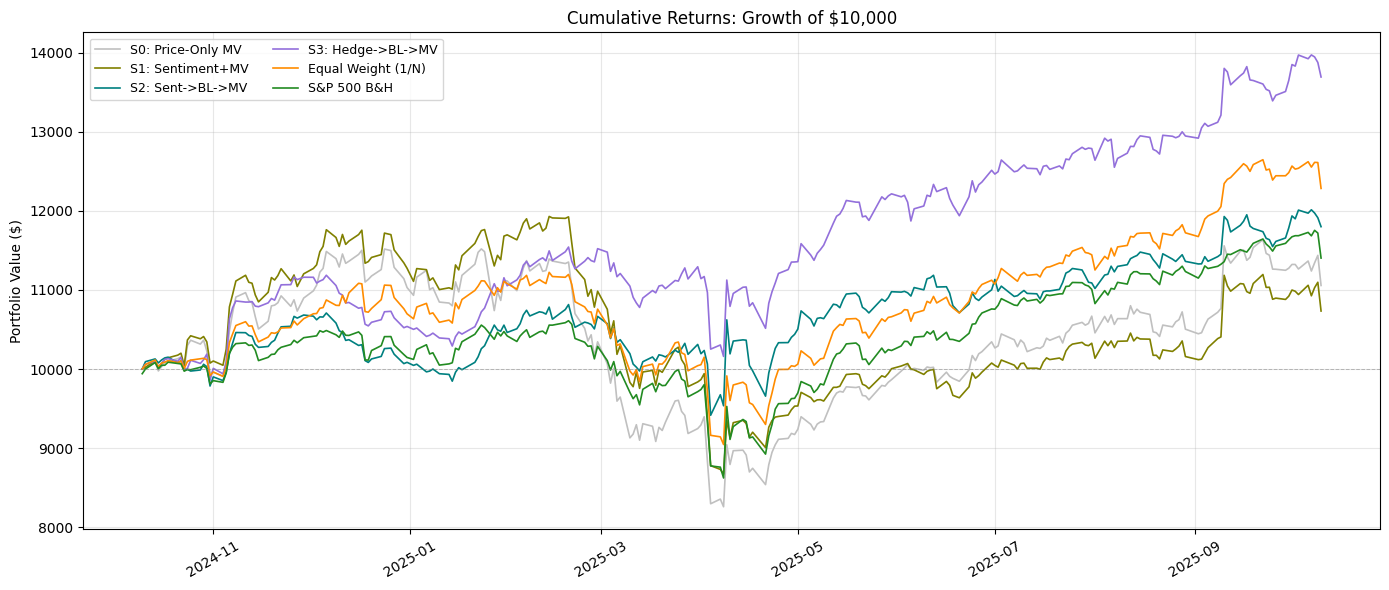

In [17]:
fig, ax = plt.subplots(figsize=(14, 6))

for name, vals in strats.items():
    linewidth = 1.2
    ax.plot(vals.index, vals.values, label=name, lw=linewidth, color=colors[name])

ax.axhline(Config['initial_capital'], color='grey', ls='--', lw=0.7, alpha=0.5)
ax.set_title(f'Cumulative Returns: Growth of ${Config["initial_capital"]:,}')
ax.set_ylabel('Portfolio Value ($)')
ax.legend(fontsize=9, ncol=2)
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Plot 2: Rolling Sharpe Ratio

Shows the 60-day rolling Sharpe ratio (annualised) for each strategy.
Unlike cumulative returns, this reveals *consistency* of risk-adjusted performance
over time rather than just the endpoint.

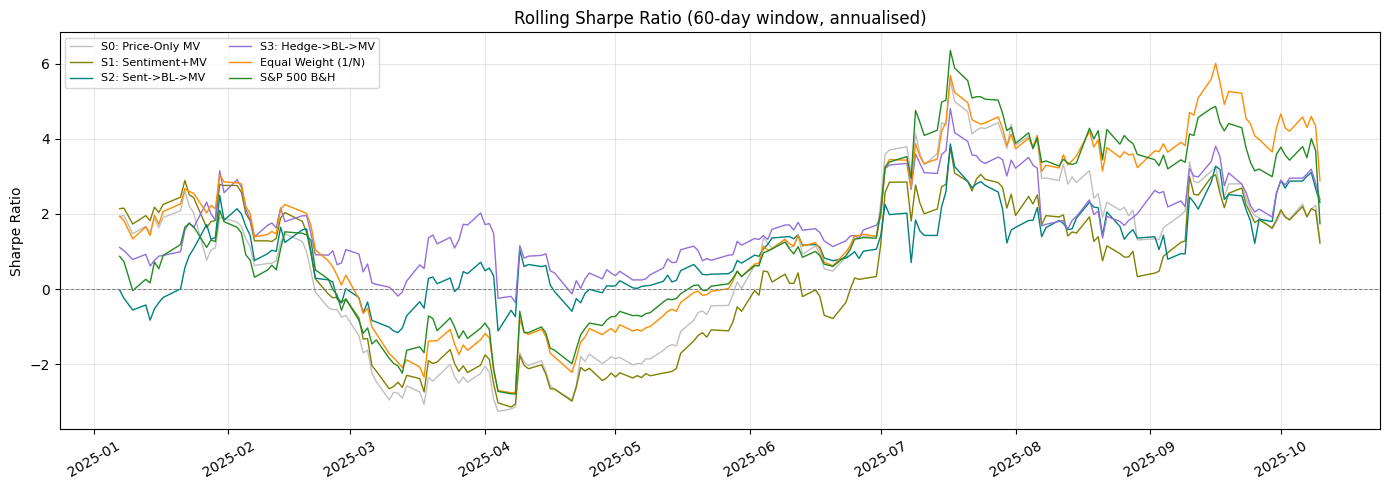

In [18]:
win = Config['rolling_sharpe_win']
fig, ax = plt.subplots(figsize=(14, 5))

for name, vals in strats.items():
    daily_ret = vals.pct_change().dropna()
    roll_mean = daily_ret.rolling(win).mean()
    roll_std  = daily_ret.rolling(win).std()
    roll_sharpe = (roll_mean / (roll_std + 1e-10)) * np.sqrt(252)

    linewidth = 1.0
    ax.plot(roll_sharpe.index, roll_sharpe.values, label=name, lw=linewidth,
            color=colors[name])

ax.axhline(0, color='grey', ls='--', lw=0.7)
ax.set_title(f'Rolling Sharpe Ratio ({win}-day window, annualised)')
ax.set_ylabel('Sharpe Ratio')
ax.legend(fontsize=8, ncol=2)
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Plot 3: Hedge Fusion Source Weights Over Time (S3 Only)

Visualises how the Hedge algorithm in S3 dynamically shifts weight between
news and tweet sentiment over time. When one source has higher recent
predictive power (measured by Spearman IC), its weight increases.

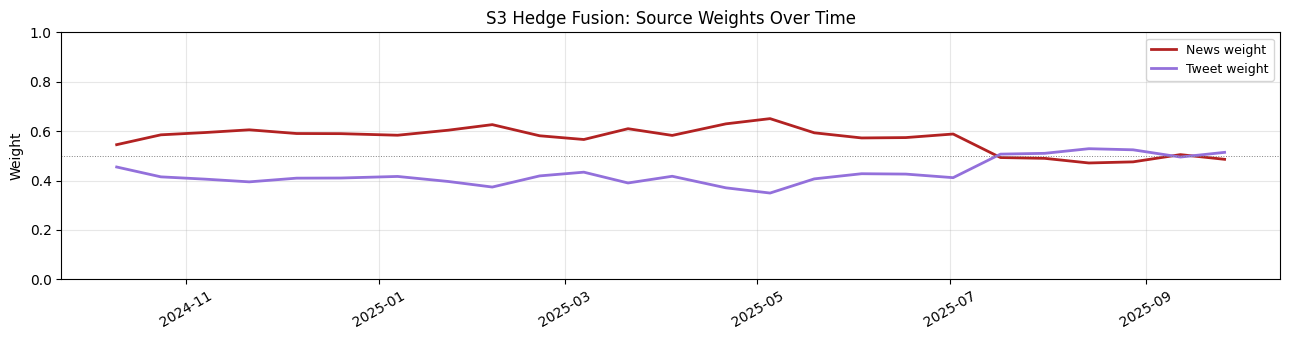

In [19]:
h_log = results['s3'].get('hedge_log', [])

if h_log:
    hedge_history_df = pd.DataFrame(h_log).set_index('date')

    fig, ax = plt.subplots(figsize=(13, 3.5))

    linewidth = 2
    ax.plot(hedge_history_df.index, hedge_history_df['w_news'],
            label='News weight', lw=linewidth, color='firebrick')
    ax.plot(hedge_history_df.index, hedge_history_df['w_tweets'],
            label='Tweet weight', lw=linewidth, color='mediumpurple')

    ax.axhline(0.5, color='grey', ls=':', lw=0.7)
    ax.set_title('S3 Hedge Fusion: Source Weights Over Time')
    ax.set_ylabel('Weight')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

### Quantitative Strategy Evaluation

Three-panel metrics table comparing all strategies:

1. **Return & Risk**: annualised return (CAGR), volatility, Sharpe ratio, Sortino ratio, Calmar ratio, and maximum drawdown
2. **Tail Risk**: Value-at-Risk (95%), Conditional VaR, skewness, kurtosis, and win rate
3. **Benchmark-Relative**: alpha, beta, information ratio, and tracking error versus S&P 500

In [ ]:
bench_key = 'S&P 500 B&H'
bench_vals = strats[bench_key]

# Panel 1: Return & Risk 

rows_rr = []
for name, vals in strats.items():
    rows_rr.append({
        'Strategy': name,
        'Total Ret': f'{total_return(vals)*100:+.2f}%',
        'CAGR': f'{ann_return(vals)*100:+.2f}%',
        'Ann Vol': f'{ann_vol(vals)*100:.2f}%',
        'Sharpe': f'{sharpe(vals):.3f}',
        'Sortino': f'{sortino(vals):.3f}',
        'Calmar': f'{calmar(vals):.3f}',
        'Max DD': f'{max_dd(vals)*100:.2f}%',
        'DD Dur (d)': int(max_dd_duration(vals)),
    })

rr_df = pd.DataFrame(rows_rr).set_index('Strategy')
rr_df = rr_df.sort_values('Sharpe', ascending=False,
                           key=lambda s: pd.to_numeric(s, errors='coerce'))

print('=' * 100)
print('  RETURN & RISK-ADJUSTED PERFORMANCE')
print('=' * 100)
display(rr_df)

# Panel 2: Tail Risk & Distribution 

rows_tail = []
for name, vals in strats.items():
    rows_tail.append({
        'Strategy': name,
        'VaR 95%': f'{var_95(vals)*100:.2f}%',
        'CVaR 95%': f'{cvar_95(vals)*100:.2f}%',
        'Skew': f'{skewness(vals):.3f}',
        'Excess Kurt': f'{kurtosis_excess(vals):.3f}',
        'Tail Ratio': f'{tail_ratio(vals):.3f}',
        'Win Rate': f'{win_rate(vals)*100:.1f}%',
        'Profit Factor': f'{profit_factor(vals):.3f}',
        'Omega': f'{omega_ratio(vals):.3f}',
    })

tail_df = pd.DataFrame(rows_tail).set_index('Strategy')

print()
print('=' * 100)
print('  TAIL RISK & RETURN DISTRIBUTION')
print('=' * 100)
display(tail_df)

# Panel 3: Benchmark-Relative (vs S&P 500) 

rows_rel = []
for name, vals in strats.items():
    ann_a, beta_val = alpha_beta(vals, bench_vals)
    ir = info_ratio(vals, bench_vals)

    daily_ret_s = daily_returns(vals)
    daily_ret_b = daily_returns(bench_vals)
    tracking_error = (daily_ret_s - daily_ret_b).dropna().std() * np.sqrt(252)

    # Up/Down capture ratios
    r_aligned = pd.concat([daily_ret_s, daily_ret_b], axis=1).dropna()
    up_days = r_aligned.iloc[:, 1] > 0
    dn_days = r_aligned.iloc[:, 1] < 0

    up_cap = (r_aligned.iloc[:, 0][up_days].mean() /
              r_aligned.iloc[:, 1][up_days].mean()) if up_days.sum() > 5 else 0.0
    dn_cap = (r_aligned.iloc[:, 0][dn_days].mean() /
              r_aligned.iloc[:, 1][dn_days].mean()) if dn_days.sum() > 5 else 0.0

    rows_rel.append({
        'Strategy': name,
        'Alpha (ann)': f'{ann_a*100:+.3f}%',
        'Beta': f'{beta_val:.3f}',
        'Info Ratio': f'{ir:.3f}',
        'Track Err': f'{tracking_error*100:.2f}%',
        'Up Capture': f'{up_cap:.3f}',
        'Dn Capture': f'{dn_cap:.3f}',
    })

rel_df = pd.DataFrame(rows_rel).set_index('Strategy')

print()
print('=' * 100)
print('  BENCHMARK-RELATIVE METRICS (vs S&P 500)')
print('=' * 100)
display(rel_df)

# Acceptance checks 

print()
print(f"horizon_days  = {Config['horizon_days']}")
print(f"slippage_bps  = {Config['slippage_bps']}")
print(f"min_weight    = {Config['min_weight']}")
print(f"shrink_covariance uses n_obs (observations) and p (assets) correctly.")

  RETURN & RISK-ADJUSTED PERFORMANCE


,Total Ret,CAGR,Ann Vol,Sharpe,Sortino,Calmar,Max DD,DD Dur (d)
Strategy,,,,,,,,
S3: Hedge->BL->MV,+36.96%,+37.13%,20.25%,1.834,2.643,3.096,-11.99%,50
Equal Weight (1/N),+22.85%,+22.96%,20.04%,1.146,1.538,1.182,-19.42%,95
S2: Sent->BL->MV,+18.01%,+18.09%,20.21%,0.895,1.342,1.396,-12.96%,56
S&P 500 B&H,+14.72%,+14.79%,19.61%,0.754,0.944,0.788,-18.76%,87
S0: Price-Only MV,+10.57%,+10.62%,26.55%,0.400,0.522,0.375,-28.32%,157
S1: Sentiment+MV,+7.34%,+7.37%,24.35%,0.303,0.394,0.270,-27.33%,165



  TAIL RISK & RETURN DISTRIBUTION


,VaR 95%,CVaR 95%,Skew,Excess Kurt,Tail Ratio,Win Rate,Profit Factor,Omega
Strategy,,,,,,,,
S0: Price-Only MV,-2.54%,-3.96%,0.189,6.729,0.855,56.4%,1.100,1.100
S1: Sentiment+MV,-2.43%,-3.65%,0.282,6.549,0.817,57.2%,1.082,1.082
S2: Sent->BL->MV,-1.43%,-2.49%,2.248,27.570,1.071,52.8%,1.210,1.210
S3: Hedge->BL->MV,-1.50%,-2.55%,1.274,15.250,1.019,56.8%,1.391,1.391
Equal Weight (1/N),-1.77%,-2.86%,1.018,14.594,0.956,57.2%,1.246,1.246
S&P 500 B&H,-1.70%,-2.87%,1.462,23.182,0.900,57.2%,1.185,1.185



  BENCHMARK-RELATIVE METRICS (vs S&P 500)


,Alpha (ann),Beta,Info Ratio,Track Err,Up Capture,Dn Capture
Strategy,,,,,,
S0: Price-Only MV,-4.344%,1.142,-0.145,14.54%,1.327,1.412
S1: Sentiment+MV,-6.019%,1.023,-0.409,13.82%,1.181,1.282
S2: Sent->BL->MV,+5.347%,0.848,0.249,11.87%,0.786,0.712
S3: Hedge->BL->MV,+20.808%,0.821,1.410,12.76%,0.907,0.679
Equal Weight (1/N),+7.292%,0.981,1.245,5.62%,1.080,1.013
S&P 500 B&H,+0.000%,1.000,0.000,0.00%,1.000,1.000



horizon_days  = 10
slippage_bps  = 2.0
min_weight    = 0.02
shrink_covariance uses n_obs (observations) and p (assets) correctly.


### Turnover & Transaction Costs

Reports the number of rebalances, average portfolio turnover per rebalance,
and total transaction costs (SEC fees + FINRA fees + slippage) for each
active strategy. Lower turnover means lower real-world friction.

In [ ]:
print('=' * 80)
print('  TURNOVER & TRANSACTION COSTS')
print('=' * 80)

# Active strategies

active_strats = {
    'S0: Price-Only MV': results['s0'],
    'S1: Sentiment+MV': results['s1'],
    'S2: Sent->BL->MV': results['s2'],
    'S3: Hedge->BL->MV': results['s3'],
}

for label, res in active_strats.items():
    to_list = res.get('turnover', [])
    cost_list = res.get('costs', [])
    avg_to = np.mean(to_list) if to_list else 0
    total_tc = np.sum(cost_list) if cost_list else 0

    print(f'\n  {label}:')
    print(f'    Rebalances        : {len(to_list)}')
    print(f'    Avg turnover/rebal: {avg_to:.4f}')
    print(f'    Total turnover    : {sum(to_list):.4f}')
    print(f'    Total tx costs    : ${total_tc:.4f}')

# Passive strategies 

print(f'\n  Equal Weight (1/N buy & hold):')
print(f'    No rebalancing - single initial purchase, buy then hold.')

print(f'\n  S&P 500 Buy&Hold:')
print(f'    No rebalancing - single initial purchase, buy then hold.')

  TURNOVER & TRANSACTION COSTS

  S0: Price-Only MV:
    Rebalances        : 25
    Avg turnover/rebal: 0.1955
    Total turnover    : 4.8876
    Total tx costs    : $10.7013

  S1: Sentiment+MV:
    Rebalances        : 25
    Avg turnover/rebal: 0.2550
    Total turnover    : 6.3751
    Total tx costs    : $13.9664

  S2: Sent->BL->MV:
    Rebalances        : 25
    Avg turnover/rebal: 0.5072
    Total turnover    : 12.6799
    Total tx costs    : $28.6326

  S3: Hedge->BL->MV:
    Rebalances        : 25
    Avg turnover/rebal: 0.4337
    Total turnover    : 10.8437
    Total tx costs    : $26.8346

  Equal Weight (1/N buy & hold):
    No rebalancing - single initial purchase, buy then hold.

  S&P 500 Buy&Hold:
    No rebalancing - single initial purchase, buy then hold.


---
## 8. Out-of-Sample Signal Analysis

Directional accuracy of the alpha signal produced by each active strategy:
how often the predicted direction matches the realised next-period return.

### Out-of-Sample Directional Accuracy & Signal Evaluation

Evaluates the quality of S3's alpha signal at each rebalance point:

- **Top-k hit rate**: how often the top-5 predicted stocks actually go up
- **Spearman IC**: rank correlation between predicted alpha and realised returns (higher = better signal)
- **Bucket spread**: mean return of top-5 minus mean return of bottom-5 stocks (measures economic value of the ranking)
- **Cumulative spread**: running total of the bucket spread over time

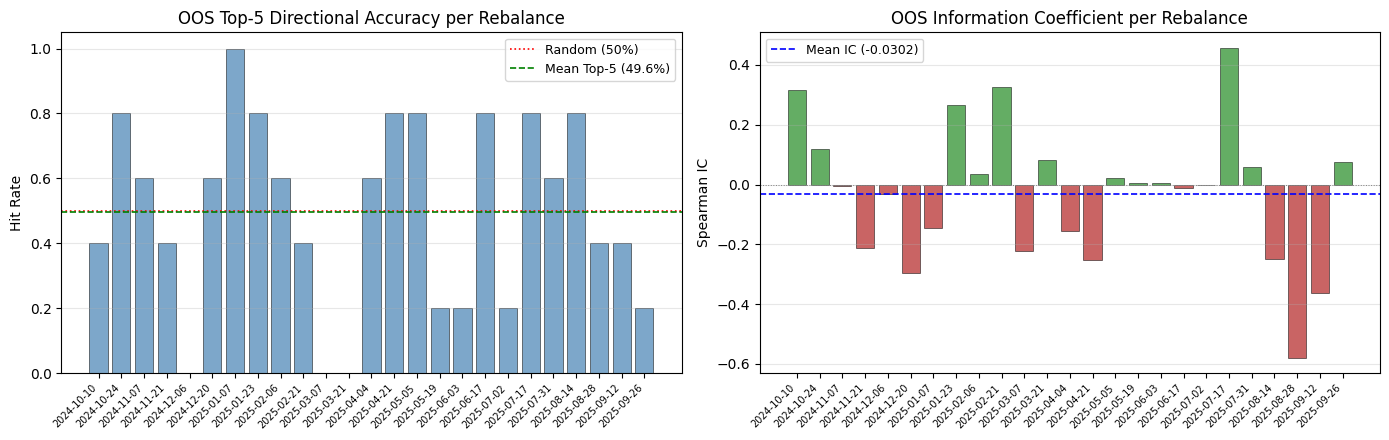

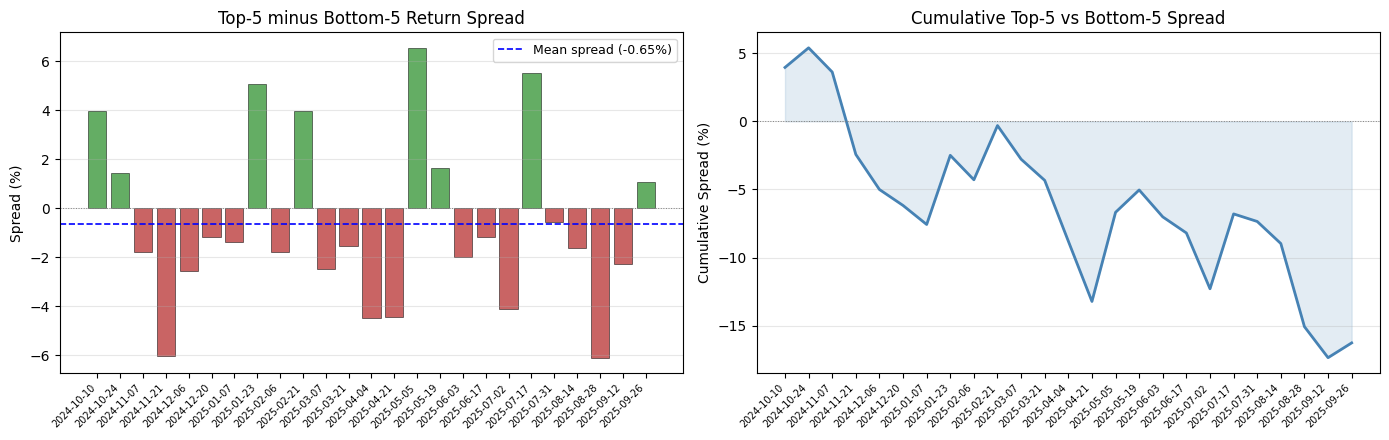

  OUT-OF-SAMPLE SIGNAL QUALITY

  Rebalances evaluated : 25
  Mean hit rate (all)  : 45.0%
  Mean hit rate (top-5): 49.6%
  Hit rate std (top-5): 29.5%
  Rebalances > 50%     : 13 / 25

  Mean OOS IC          : -0.0302
  IC std               : 0.2340
  IC t-stat            : -0.65
  IC_IR (mean/std)     : -0.1290
  Positive IC rebal    : 12 / 25

  --- Bucket Spread (Top-5 vs Bottom-5) ---
  Mean spread          : -0.651%
  Spread std           : 3.500%
  Spread t-stat        : -0.93
  Mean top-5 return  : 0.451%
  Mean bottom-5 return: 1.102%
  Positive spread rebal: 8 / 25




,hit_rate_all,hit_rate_topk,oos_ic,topk_mean,bottomk_mean,spread,n_stocks
date,,,,,,,
2024-10-10,50%,40%,0.3158,0.19%,-3.77%,3.96%,20
2024-10-24,45%,80%,0.1188,5.24%,3.80%,1.44%,20
2024-11-07,50%,60%,-0.0060,1.94%,3.72%,-1.78%,20
2024-11-21,40%,40%,-0.2135,-0.16%,5.89%,-6.05%,20
2024-12-06,40%,0%,-0.0331,-5.68%,-3.10%,-2.57%,20
2024-12-20,35%,60%,-0.2947,-0.65%,0.52%,-1.17%,20
2025-01-07,60%,100%,-0.1444,3.71%,5.10%,-1.40%,20
2025-01-23,55%,80%,0.2662,3.29%,-1.79%,5.08%,20
2025-02-06,60%,60%,0.0361,-1.85%,-0.06%,-1.79%,20


In [ ]:
alpha_log = results['s3'].get('alpha_log', [])
rebal_K = Config['rebalance_days']
topk = Config['topk_eval']

if not alpha_log:
    print('No alpha predictions logged.')
else:
    hit_rows = []

    for entry in alpha_log:
        date_idx = entry['date_idx']
        eidx = entry['eidx']
        alpha = entry['alpha']
        current_date = entry['date']

        # Realized return over next rebalance period
        fwd_idx = min(date_idx + rebal_K, len(trading_dates) - 1)
        if fwd_idx <= date_idx:
            continue

        fwd_close = close_panel.iloc[fwd_idx].values
        cur_close = close_panel.iloc[date_idx].values

        realized = np.full(len(eidx), np.nan)
        for j, ti in enumerate(eidx):
            if cur_close[ti] > 0 and fwd_close[ti] > 0:
                realized[j] = np.log(fwd_close[ti] / cur_close[ti])

        valid = np.isfinite(realized)
        if valid.sum() < 3:
            continue

        alpha_valid = alpha[valid]
        realized_valid = realized[valid]

        # All-stocks hit rate
        hits_all = (np.sign(alpha_valid) == np.sign(realized_valid)).sum()
        num_valid = len(alpha_valid)
        hit_rate_all = hits_all / num_valid

        # Top-K hit rate (long-only aware)
        k = min(topk, num_valid)
        topk_idx = np.argsort(alpha_valid)[-k:]
        bottomk_idx = np.argsort(alpha_valid)[:k]
        hits_topk = (np.sign(alpha_valid[topk_idx]) == np.sign(realized_valid[topk_idx])).sum()
        hit_rate_topk = hits_topk / k

        # Bucket spread: top-k vs bottom-k mean realized returns
        topk_mean = realized_valid[topk_idx].mean()
        bottomk_mean = realized_valid[bottomk_idx].mean()
        spread = topk_mean - bottomk_mean

        # Spearman IC
        spearman_corr, _ = spearmanr(alpha_valid, realized_valid)

        hit_rows.append({
            'date': current_date,
            'hit_rate_all': hit_rate_all,
            'hit_rate_topk': hit_rate_topk,
            'hits_all': int(hits_all),
            'n_stocks': num_valid,
            'oos_ic': spearman_corr if not np.isnan(spearman_corr) else 0.0,
            'topk_mean': topk_mean,
            'bottomk_mean': bottomk_mean,
            'spread': spread,
        })

    if hit_rows:
        hit_rate_df = pd.DataFrame(hit_rows).set_index('date')

        #  Plot 1: Hit rate and OOS IC over time 

        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

        ax = axes[0]
        ax.bar(range(len(hit_rate_df)), hit_rate_df['hit_rate_topk'],
               color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.axhline(0.5, color='red', ls=':', linewidth=1.2, label='Random (50%)')
        mean_hr_topk = hit_rate_df['hit_rate_topk'].mean()
        ax.axhline(mean_hr_topk, color='green', ls='--', linewidth=1.2,
                   label=f'Mean Top-{topk} ({mean_hr_topk*100:.1f}%)')
        ax.set_xticks(range(len(hit_rate_df)))
        ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in hit_rate_df.index],
                           rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Hit Rate')
        ax.set_title(f'OOS Top-{topk} Directional Accuracy per Rebalance')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3, axis='y')

        ax = axes[1]
        ic_bar_colors = ['forestgreen' if v > 0 else 'firebrick'
                         for v in hit_rate_df['oos_ic']]
        ax.bar(range(len(hit_rate_df)), hit_rate_df['oos_ic'],
               color=ic_bar_colors, alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.axhline(0, color='grey', ls=':', linewidth=0.7)
        mean_ic = hit_rate_df['oos_ic'].mean()
        ax.axhline(mean_ic, color='blue', ls='--', linewidth=1.2,
                   label=f'Mean IC ({mean_ic:.4f})')
        ax.set_xticks(range(len(hit_rate_df)))
        ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in hit_rate_df.index],
                           rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Spearman IC')
        ax.set_title('OOS Information Coefficient per Rebalance')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3, axis='y')

        plt.tight_layout()
        plt.show()

        #  Plot 2: Bucket spread over time 

        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

        ax = axes[0]
        spread_bar_colors = ['forestgreen' if v > 0 else 'firebrick'
                             for v in hit_rate_df['spread']]
        ax.bar(range(len(hit_rate_df)), hit_rate_df['spread'] * 100,
               color=spread_bar_colors, alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.axhline(0, color='grey', ls=':', linewidth=0.7)
        mean_spread = hit_rate_df['spread'].mean()
        ax.axhline(mean_spread * 100, color='blue', ls='--', linewidth=1.2,
                   label=f'Mean spread ({mean_spread*100:.2f}%)')
        ax.set_xticks(range(len(hit_rate_df)))
        ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in hit_rate_df.index],
                           rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Spread (%)')
        ax.set_title(f'Top-{topk} minus Bottom-{topk} Return Spread')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3, axis='y')

        ax = axes[1]
        cumulative_spread = hit_rate_df['spread'].cumsum() * 100
        ax.plot(range(len(hit_rate_df)), cumulative_spread,
                color='steelblue', linewidth=2)
        ax.fill_between(range(len(hit_rate_df)), 0, cumulative_spread,
                        alpha=0.15, color='steelblue')
        ax.set_xticks(range(len(hit_rate_df)))
        ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in hit_rate_df.index],
                           rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Cumulative Spread (%)')
        ax.set_title(f'Cumulative Top-{topk} vs Bottom-{topk} Spread')
        ax.axhline(0, color='grey', ls=':', linewidth=0.7)
        ax.grid(alpha=0.3, axis='y')

        plt.tight_layout()
        plt.show()

        # Summary stats

        mean_hr_all = hit_rate_df['hit_rate_all'].mean()
        num_rebalances = len(hit_rate_df)
        ic_std = hit_rate_df['oos_ic'].std()
        ic_tstat = mean_ic / (ic_std / np.sqrt(num_rebalances)) if ic_std > 0 else 0.0
        spread_std = hit_rate_df['spread'].std()
        spread_tstat = mean_spread / (spread_std / np.sqrt(num_rebalances)) if spread_std > 0 else 0.0

        print('=' * 80)
        print('  OUT-OF-SAMPLE SIGNAL QUALITY')
        print('=' * 80)
        print(f'\n  Rebalances evaluated : {num_rebalances}')
        print(f'  Mean hit rate (all)  : {mean_hr_all*100:.1f}%')
        print(f'  Mean hit rate (top-{topk}): {mean_hr_topk*100:.1f}%')
        print(f'  Hit rate std (top-{topk}): {hit_rate_df["hit_rate_topk"].std()*100:.1f}%')
        print(f'  Rebalances > 50%     : {(hit_rate_df["hit_rate_topk"] > 0.5).sum()} / {num_rebalances}')

        print(f'\n  Mean OOS IC          : {mean_ic:.4f}')
        print(f'  IC std               : {ic_std:.4f}')
        print(f'  IC t-stat            : {ic_tstat:.2f}')
        print(f'  IC_IR (mean/std)     : {mean_ic / ic_std if ic_std > 0 else 0:.4f}')
        print(f'  Positive IC rebal    : {(hit_rate_df["oos_ic"] > 0).sum()} / {num_rebalances}')

        print(f'\n  --- Bucket Spread (Top-{topk} vs Bottom-{topk}) ---')
        print(f'  Mean spread          : {mean_spread*100:.3f}%')
        print(f'  Spread std           : {spread_std*100:.3f}%')
        print(f'  Spread t-stat        : {spread_tstat:.2f}')
        print(f'  Mean top-{topk} return  : {hit_rate_df["topk_mean"].mean()*100:.3f}%')
        print(f'  Mean bottom-{topk} return: {hit_rate_df["bottomk_mean"].mean()*100:.3f}%')
        print(f'  Positive spread rebal: {(hit_rate_df["spread"] > 0).sum()} / {num_rebalances}')

        # Per-rebalance table

        print('\n')
        hr_display = hit_rate_df[['hit_rate_all', 'hit_rate_topk', 'oos_ic',
                                  'topk_mean', 'bottomk_mean', 'spread', 'n_stocks']].copy()
        hr_display['hit_rate_all'] = hr_display['hit_rate_all'].map(lambda x: f'{x*100:.0f}%')
        hr_display['hit_rate_topk'] = hr_display['hit_rate_topk'].map(lambda x: f'{x*100:.0f}%')
        hr_display['oos_ic'] = hr_display['oos_ic'].map(lambda x: f'{x:.4f}')
        hr_display['topk_mean'] = hr_display['topk_mean'].map(lambda x: f'{x*100:.2f}%')
        hr_display['bottomk_mean'] = hr_display['bottomk_mean'].map(lambda x: f'{x*100:.2f}%')
        hr_display['spread'] = hr_display['spread'].map(lambda x: f'{x*100:.2f}%')
        display(hr_display)
    else:
        print('No valid hit rate observations (all forward returns missing).')

---
## Summary

This notebook implements a complete quantitative trading system with:

- **Data pipeline**: sentiment from 20-stock news & tweet CSVs,
  OHLCV prices fetched via yfinance, unified panel construction.
- **Feature engine**: 8 cross-sectionally z-scored factors
  (2 sentiment + 4 technical + 2 sentiment-derived) with no forward-looking leakage.
- **Four progressive strategies** evaluated on the same backtest window:
  - **S0** Price-Only Markowitz (no sentiment baseline)
  - **S1** Sentiment tilt + MV (single-source news tilt)
  - **S2** Sentiment → Black-Litterman → MV (Bayesian blending, single source)
  - **S3** Hedge Fusion → BL → MV (adaptive multi-source weighting via Hedge algorithm)
- **Two benchmarks**: Equal Weight (1/N buy & hold) and S&P 500 Buy & Hold.
- **Black-Litterman**: converts alpha to posterior expected returns with
  view uncertainty scaled by data confidence.
- **Mean-Variance optimisation**: long-only constrained with turnover penalty,
  min-weight cutoff to avoid over-diversification.
- **Position-based backtest**: configurable rebalance cycle, signal at *t*, execute at *t+1*,
  transaction costs (SEC fee + FINRA fee + slippage).
- **Backtest window**: 2024-10-10 to 2025-10-10, with full warmup (covariance,
  features) using data before the start date.
- **Quantitative evaluation**: 3-panel metrics (return/risk, tail risk, benchmark-relative).
- **Portfolio breakdown**: full weight log at every rebalance with stacked bar visualisation.

---
## Methodology Notes

### Cross-Sectional Normalisation
- **Winsorise + z-score** clips extreme values at the 1st/99th percentiles before standardising, reducing the influence of outliers on factor scores (Jegadeesh & Titman, 1993).
- **Rank > inverse-normal** is a non-parametric alternative that maps cross-sectional ranks to standard normal quantiles, ensuring robustness to distributional assumptions (Bliss & Panigirtzoglou, 2004).

### Momentum & Reversal Factors
- **Momentum** (Jegadeesh & Titman, 1993): stocks with higher past returns tend to continue outperforming over medium horizons (20–60 days). We use log-return over trailing windows as the momentum signal.
- **Short-term reversal** (Lehmann, 1990; Lo & MacKinlay, 1990): returns over very short horizons (5–10 days) exhibit mean-reversion. The reversal factor is the negative of short-horizon momentum.

### Black–Litterman View Confidence
- View confidence (Ω) is modulated by three factors: (1) **signal strength** stronger alpha convictions receive tighter uncertainty, (2) **sentiment dispersion**  disagreement between news and tweet sentiment increases uncertainty, and (3) **data missingness** missing sentiment sources reduce confidence (Black & Litterman, 1992; He & Litterman, 1999).
- The confidence mapping `conf = base × miss_penalty × strength × disp_penalty` is clipped to `[conf_min, conf_max]` for stability.

### Signal Evaluation
- **Information Coefficient (IC)**: cross-sectional Spearman rank correlation between predicted alpha and realised forward returns (Grinold & Kahn, 2000).
- **Top-k hit rate**: directional accuracy restricted to the top-k stocks by predicted alpha, measuring the practical accuracy of the long-only signal.
- **Bucket spread**: the difference in mean realised returns between the top-k and bottom-k stocks, providing a direct measure of signal monotonicity and economic value (Qian, Hua & Sorensen, 2007).

### References
1. Black, F. & Litterman, R. (1992). Global portfolio optimization. *Financial Analysts Journal*, 48(5), 28–43.
2. He, G. & Litterman, R. (1999). The intuition behind Black-Litterman model portfolios. *Goldman Sachs Asset Management Working Paper*.
3. Jegadeesh, N. & Titman, S. (1993). Returns to buying winners and selling losers. *Journal of Finance*, 48(1), 65–91.
4. Lehmann, B. (1990). Fads, martingales, and market efficiency. *Quarterly Journal of Economics*, 105(1), 1–28.
5. Lo, A. & MacKinlay, A. (1990). When are contrarian profits due to stock market overreaction? *Review of Financial Studies*, 3(2), 175–205.
6. Grinold, R. & Kahn, R. (2000). *Active Portfolio Management*. McGraw-Hill.
7. Qian, E., Hua, R. & Sorensen, E. (2007). *Quantitative Equity Portfolio Management*. Chapman & Hall.
8. Bliss, R. & Panigirtzoglou, N. (2004). Option-implied risk aversion estimates. *Journal of Finance*, 59(1), 407–446.